# Parameter Sensitivity of the LIF Neuron

The previous notebook validated the analytical firing rate against numerical simulation. This notebook uses the analytical F–I relationship to examine how three model parameters shape neuronal firing:

- membrane capacitance $C_m$,
- membrane resistance $R_m$, and
- absolute refractory period $T_{\mathrm{ref}}$.

Each parameter is varied while the others are held fixed. This isolates its effect on the rheobase, membrane charging time, F–I curve, and maximum firing rate.

The baseline parameters are

$$
E_L=V_{\mathrm{reset}}=-65\,\mathrm{mV},
\qquad
V_{\mathrm{threshold}}=-50\,\mathrm{mV},
$$

$$
R_m=100\,\mathrm{M\Omega},
\qquad
C_m=200\,\mathrm{pF},
\qquad
T_{\mathrm{ref}}=2\,\mathrm{ms}.
$$

In [108]:
import numpy as np
import matplotlib.pyplot as plt 


def analytical_firing_rate(
    i,
    t_refractory,
    v_threshold,
    v_reset,
    e_l,
    r_m,
    c_m
):
    I_rh = (v_threshold - e_l)/r_m
    tau = r_m * c_m

    F = np.zeros_like(i)

    above_rheobase = i > I_rh
    v_inf = r_m * i[above_rheobase] + e_l
    T = tau * np.log((v_reset - v_inf)/(v_threshold - v_inf))

    F[above_rheobase] = 1 / (t_refractory + T)

    return F, I_rh

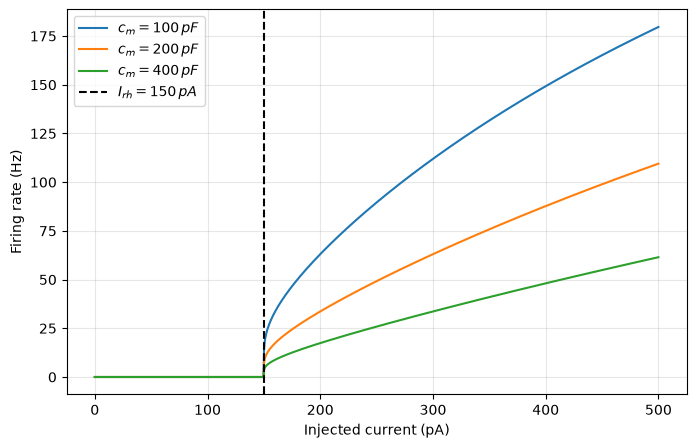

In [109]:
capacitances = np.array([100 , 200, 400]) * 1e-12
i = np.linspace(0, 500, 1000) * 1e-12

plt.figure(figsize=(8, 5))
for c_m in capacitances:
    frequency, I_rh = analytical_firing_rate(
        i = i,
        t_refractory = 2 * 1e-3,
        v_threshold = -50e-3, 
        v_reset = -65e-3, 
        e_l = -65e-3, 
        r_m = 100e6, 
        c_m = c_m
        )
    
    plt.plot(i * 1e12, frequency, label = fr'$c_{{m}} = {c_m * 1e12:.0f}\, {{pF}} $')


plt.axvline(
    I_rh * 1e12,
    color='black',
    linestyle='--',
    label = fr'$I_{{rh}} = {I_rh * 1e12:.0f} \, {{pA}}$'
)

plt.xlabel('Injected current (pA)')
plt.ylabel('Firing rate (Hz)')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

## Effect of membrane capacitance

All three capacitance values produce the same rheobase:

$$
I_{\mathrm{rh}}
=
\frac{V_{\mathrm{threshold}}-E_L}{R_m}
=
150\,\mathrm{pA}.
$$

This is expected because $C_m$ does not appear in the rheobase equation. It instead changes the membrane time constant:

$$
\tau_m=R_mC_m.
$$

Increasing $C_m$ increases the amount of charge required to change the membrane voltage. The membrane therefore reaches threshold more slowly, producing a lower firing rate above rheobase:

$$
C_m\uparrow
\Rightarrow
\tau_m\uparrow
\Rightarrow
T_{\mathrm{charge}}\uparrow
\Rightarrow
f\downarrow.
$$

Membrane capacitance therefore controls the speed of voltage integration without changing the minimum current required for repetitive firing.

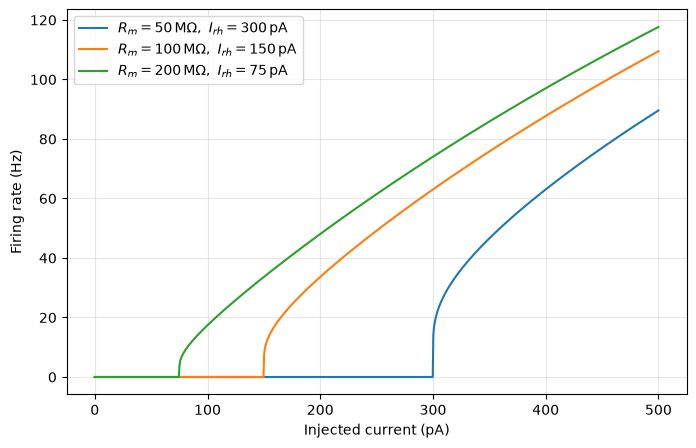

In [110]:
resistances = np.array([50, 100, 200]) * 1e6
i = np.linspace(0, 500, 1000) * 1e-12

plt.figure(figsize=(8, 5))
for r_m in resistances:
    frequency, I_rh = analytical_firing_rate(
        i = i,
        t_refractory = 2 * 1e-3,
        v_threshold = -50e-3, 
        v_reset = -65e-3, 
        e_l = -65e-3, 
        r_m = r_m, 
        c_m = 200 * 1e-12
        )
    
    plt.plot(i * 1e12, frequency, label=fr'$R_m={r_m / 1e6:.0f}\,\mathrm{{M\Omega}},\ I_{{rh}}={I_rh * 1e12:.0f}\,\mathrm{{pA}}$')


plt.xlabel('Injected current (pA)')
plt.ylabel('Firing rate (Hz)')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

## Effect of membrane resistance

Changing $R_m$ affects both the membrane time constant and the rheobase:

$$
\tau_m=R_mC_m,
\qquad
I_{\mathrm{rh}}
=
\frac{V_{\mathrm{threshold}}-E_L}{R_m}.
$$

The tested resistance values give

$$
\begin{array}{c|c|c}
R_m & \tau_m & I_{\mathrm{rh}}\\
\hline
50\,\mathrm{M\Omega} & 10\,\mathrm{ms} & 300\,\mathrm{pA}\\
100\,\mathrm{M\Omega} & 20\,\mathrm{ms} & 150\,\mathrm{pA}\\
200\,\mathrm{M\Omega} & 40\,\mathrm{ms} & 75\,\mathrm{pA}
\end{array}
$$

A larger membrane resistance shifts the F–I curve to the left because the same current produces a larger steady-state voltage displacement:

$$
V_\infty-E_L=R_mI_0.
$$

Consequently, less current is required to reach threshold. Unlike capacitance, resistance affects both temporal integration and neuronal excitability, so its effect cannot be interpreted through $\tau_m$ alone.

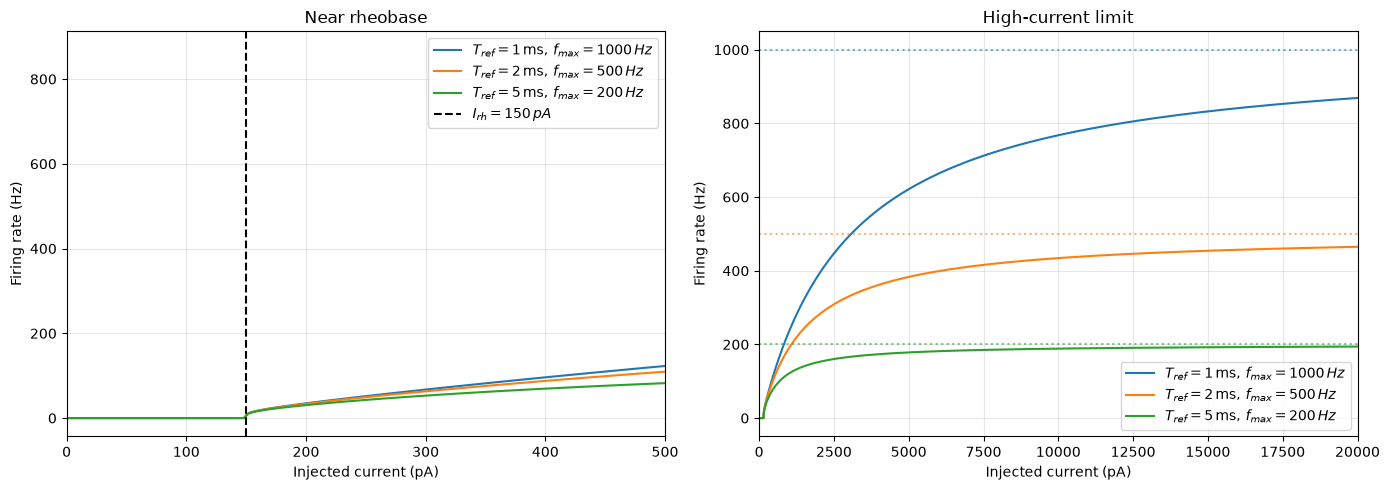

In [ ]:
refractory_periods = np.array([1, 2, 5]) * 1e-3
i = np.linspace(0, 20000, 5000) * 1e-12

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for t_refractory in refractory_periods:
    frequency, I_rh = analytical_firing_rate(
        i = i,
        t_refractory = t_refractory,
        v_threshold = -50e-3, 
        v_reset = -65e-3, 
        e_l = -65e-3, 
        r_m = 100e6, 
        c_m = 200 * 1e-12
        )
    fmax = 1/t_refractory
    label = (fr'$T_{{ref}}={t_refractory * 1e3:.0f}\,\mathrm{{ms}},\, f_{{max}} = {fmax:.0f} \, Hz$')

    axes[0].plot(i * 1e12, frequency, label = label)
    line, = axes[1].plot(i * 1e12, frequency, label = label)
    axes[1].axhline(fmax, color = line.get_color(), linestyle = ':', alpha=0.6)

axes[0].axvline(
    I_rh * 1e12,
    color='black',
    linestyle='--',
    label = fr'$I_{{rh}} = {I_rh * 1e12:.0f} \, {{pA}}$'    
)

axes[0].set_xlim(0, 500)
axes[0].set_title('Near rheobase')
axes[1].set_xlim(0, 20000)
axes[1].set_title('High-current limit')

for ax in axes:
    ax.set_xlabel('Injected current (pA)')
    ax.set_ylabel('Firing rate (Hz)')
    ax.grid(alpha = 0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Effect of the refractory period

Changing $T_{\mathrm{ref}}$ does not affect the membrane equation, time constant, or rheobase. It adds a fixed delay to every interspike interval:

$$
T_{\mathrm{total}}
=
T_{\mathrm{charge}}+T_{\mathrm{ref}}.
$$

Near rheobase, $T_{\mathrm{charge}}$ is large, so the relative effect of the refractory period is small. At high currents, the charging time approaches zero and the refractory period becomes the main limitation:

$$
\lim_{I_0\to\infty}f(I_0)
=
\frac{1}{T_{\mathrm{ref}}}.
$$

Therefore,

$$
\begin{array}{c|c}
T_{\mathrm{ref}} & f_{\max}\\
\hline
1\,\mathrm{ms} & 1000\,\mathrm{Hz}\\
2\,\mathrm{ms} & 500\,\mathrm{Hz}\\
5\,\mathrm{ms} & 200\,\mathrm{Hz}
\end{array}
$$

## Conclusion

The three parameters influence distinct aspects of LIF behavior:

$$
\begin{array}{c|c|c|c}
\text{Parameter increased} &
I_{\mathrm{rh}} &
\tau_m &
f_{\max}\\
\hline
C_m & \text{unchanged} & \text{increases} & \text{unchanged}\\
R_m & \text{decreases} & \text{increases} & \text{unchanged}\\
T_{\mathrm{ref}} & \text{unchanged} & \text{unchanged} & \text{decreases}
\end{array}
$$

Thus, membrane capacitance primarily controls integration speed, membrane resistance strongly affects excitability, and the refractory period limits the maximum sustainable firing rate.